# 🚚 Sevkiyat Gecikme Riski — ML Pipeline (Öğretim / Demo Katmanı)

Bu notebook, `AI-Powered Logistics Early Warning` projesinin **anlatı katmanıdır**.
Amacı bir üretim modeli teslim etmek değil; *"yapay zeka bu kararı nasıl veriyor?"*
sorusunu adım adım, görülebilir biçimde göstermektir.

Üretim scoring'i `src/ml_delay_risk_pipeline.py` içinde yaşar ve Power BI raporunu
besleyen `Fact_Shipments_with_ML.csv` dosyasını **yalnızca o script** üretir.
Bu notebook ona hiç dokunmaz (bkz. Bölüm 7).

---

## ⚠️ Metodolojik Uyarı — Bunu Okumadan Sonuçları Yorumlamayın

**Bu notebookta kullanılan veri sentetiktir ve veri üretim süreci (DGP) bizim
tarafımızdan yazılmıştır.** Bu, sonuçların nasıl okunacağını doğrudan etkiler:

| Bu notebook **kanıtlar** | Bu notebook **kanıtlamaz** |
|---|---|
| Pipeline'ın metodolojik olarak doğru kurulduğunu (encoding, split, leakage yok) | Modelin gerçek dünya sevkiyat verisinde bu performansı vereceğini |
| Random Forest'ın gürültülü bir olasılıksal süreçten sinyal çıkarabildiğini | Feature importance sıralamasının gerçek bir keşif olduğunu |
| Risk skorunun BI katmanına nasıl taşınacağını | Modelin ticari değerini veya ROI'sini |

**Feature importance hakkında özel uyarı:** Sentetik veride bir değişkenin "önemli"
çıkması, o değişkeni jeneratöre biz ağırlıklı koyduğumuz içindir. Yani grafikteki
sıralama bir *bulgu* değil, kendi varsayımlarımızın **geri okunmasıdır**. Grafiği
"modelimiz doğru şeye bakmayı öğrenmiş mi?" diye bir **doğrulama (sanity check)**
aracı olarak okuyun, "tedarikçi puanı gecikmenin en büyük nedeni" diye bir iş
içgörüsü olarak değil.

### Bu sürümde neyin düzeltildiği

Bu notebook'un önceki sürümünde **sirküler bir hedef değişken** vardı: `Risk_Level`
deterministik bir formülden (`traffic*35 + weather*40 + vendor_rating*15 + ...`)
üretiliyor, sonra **tam olarak aynı değişkenler** modele feature olarak veriliyordu.
Model gizli bir örüntü öğrenmiyor, kendi yazdığımız formülü cebirsel olarak tersine
çözüyordu. Raporlanan %86 accuracy bir genelleme başarısı değil, formül çözme
başarısıydı — ve indirgenemez belirsizliği (Bayes hatası) neredeyse sıfır olan bir
problemde accuracy raporlamak anlamsızdır.

**Düzeltme:** Hedef artık deterministik bir kuraldan değil, **gözlemlenen bir
sonuçtan** türetiliyor: `is_delayed = (Actual_Delay_Days > 0)`. `Actual_Delay_Days`
sürekli bir gecikme eğiliminin gürültü eklenip **yuvarlanması ve kırpılmasıyla**
üretilir; bu bilgi kaybı, aynı feature vektörüne sahip iki sevkiyatın farklı
sonuçlanabilmesi anlamına gelir. Böylece gerçek bir belirsizlik doğar ve model
formül çözmek yerine **olasılık tahmin etmek** zorunda kalır.

`Risk_Level` ise artık modelin **girdisi değil, çıktısıdır**: `predict_proba`
sonucunun binlenmesiyle üretilir (Bölüm 6) — `src/ml_delay_risk_pipeline.py` ile
birebir aynı yaklaşım.

## Bölüm 0 — Kütüphaneler

`LabelEncoder` bilinçli olarak **kaldırıldı**; gerekçesi Bölüm 3'te.
Bunun yerine `ColumnTransformer` + `Pipeline` + `OneHotEncoder` kullanıyoruz;
bu, `src/ml_delay_risk_pipeline.py` ile aynı yaklaşımdır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    cross_val_predict, StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit,
)
from copy import deepcopy
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score,
    brier_score_loss,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("✅ Kütüphaneler yüklendi.")
print(f"   pandas {pd.__version__} | seaborn {sns.__version__}")

✅ Kütüphaneler yüklendi.
   pandas 3.0.5 | seaborn 0.13.2


## Bölüm 1 — Veri Üretimi (`src/` şemasıyla uyumlu)

Notebook portfolyo amaçlı **tek başına çalışabilir** olmalı, bu yüzden kendi
verisini üretiyor. Ancak önceki sürümden iki kritik farkla:

**1. Şema uyumu.** Önceki sürüm `src/` katmanından bağımsız, çakışan bir şema
üretiyordu: `Vendor_ID` `VND-101` (src: `VEND-001`), `Route_ID` hiçbir boyut
tablosuna bağlanmayan serbest bir etiket, `Vehicle_Type` Türkçe (`Dizel Tır`) ama
src İngilizce (`Diesel Truck`), 1000 satır (src: 1500). Artık **src ile aynı
alfabeyi** konuşuyoruz: `VEND-0NN`, `RT-000NN` (gerçek rota kombinasyonlarından
`etl_star_schema.py` mantığıyla türetilmiş), İngilizce araç tipleri, 1500 satır.

**1b. Zaman ve mevsimsellik.** Her sevkiyata son 12 ay içinde bir `Shipment_Date`
atanıyor (yıl sonu tatil sezonunda hacim artıyor) ve **hava koşulu artık aya bağlı**:
kuzey yarımküre döngüsüyle Kasım–Şubat arası Snow/Storm olasılığı yükseliyor,
Haziran–Ağustos'ta Normal baskın (Temmuz'da Snow olasılığı sıfır).

Tasarım kuralı: **mevsimsellik yalnızca hangi havanın hangi ayda daha sık
görüldüğünü belirler.** Havanın gecikmeye etkisi ve tedarikçiyle etkileşimi hiç
değişmez. Zincir şu: `ay → hava dağılımı → (hava × tedarikçi) → gecikme`. Yeni bir
sinyal eklenmiyor, var olan sinyale zaman düzeni kazandırılıyor. Aylık dağılımlar,
**yıllık marjinal** hava dağılımı eski sabit değere yakın kalacak şekilde seçildi;
aşağıdaki hücre bunu doğruluyor.

**2. Gecikme iki aşamalı olasılıksal bir *sonuç* olarak üretiliyor** (zero-inflated /
hurdle yapı), `src/generate_logistics_data.py` ile birebir aynı katsayılarla:

- **Aşama 1 — gecikecek mi?** Hava, trafik, tedarikçi puanı ve mesafe bir *logit*
  oluşturur; `sigmoid` ile olasılığa çevrilir; **Bernoulli çekilişi** yapılır.
- **Aşama 2 — kaç gün?** Yalnızca gecikenler için `1..5` arası kesilmiş Poisson.

Aynı feature vektörüne sahip iki sevkiyat farklı sonuçlanabilir — model artık bir
denklem çözmüyor, **olasılık tahmin ediyor**.

Ayrıca bir **hava × tedarikçi etkileşimi** var: toplamsal bir modelde kötü hava
neredeyse herkesi eşiğin üstüne iter ve tedarikçi kalitesinin önemi silinir (tavan
etkisi). Etkileşim terimi ortalama puan etrafında merkezlendiği için çarpanı
büyütmek ortalamayı değil **yayılımı** artırır: iyi tedarikçi fırtınada daha az,
kötüsü daha çok vurulur — havanın marjinal etkisi ise büyük ölçüde korunur.

> **Not:** Önceki revizyonda gecikme toplamsal bir skordan üretiliyordu ve tüm
> bileşenler pozitif olduğu için sevkiyatların **%91'i** gecikiyordu. Storm/Snow/High
> altında oran %100'e dayanıyor, yani bu değişkenlerin hiçbir ayrım gücü kalmıyordu.
> Aşağı akışta Power BI'daki `High Risk Rate %` = %84.3 çıkıyordu — sevkiyatların
> %84'ünün kırmızı yandığı bir erken uyarı paneli hiçbir şey uyarmaz.

✅ 1500 satırlık veri seti üretildi (1346 benzersiz rota).
   Tarih aralığı: 2025-08-01 .. 2026-07-31

--- Gecikme mantığı doğrulaması: ortalama gecikme, havaya göre ---
Weather_Condition
Storm     0.98
Snow      0.79
Rain      0.40
Normal    0.21
Name: Actual_Delay_Days, dtype: float64

--- Yıllık marjinal hava dağılımı (eski sabit değerle kıyas) ---
        Yeni (mevsimsel)  Eski (sabit)
Normal             0.579           0.6
Rain               0.207           0.2
Storm              0.085           0.1
Snow               0.129           0.1

--- Aylık hava dağılımı (%) ve gerçekleşen gecikme oranı ---
Weather_Condition  Normal  Rain  Storm  Snow  Sevkiyat  Gecikme_%
Ay                                                               
1                    26.8  20.6   17.5  35.1        97       28.9
2                    25.9  12.0   14.8  47.2       108       33.3
3                    46.4  32.1    9.8  11.6       112       20.5
4                    68.5  23.4    4.8   3.2       124      

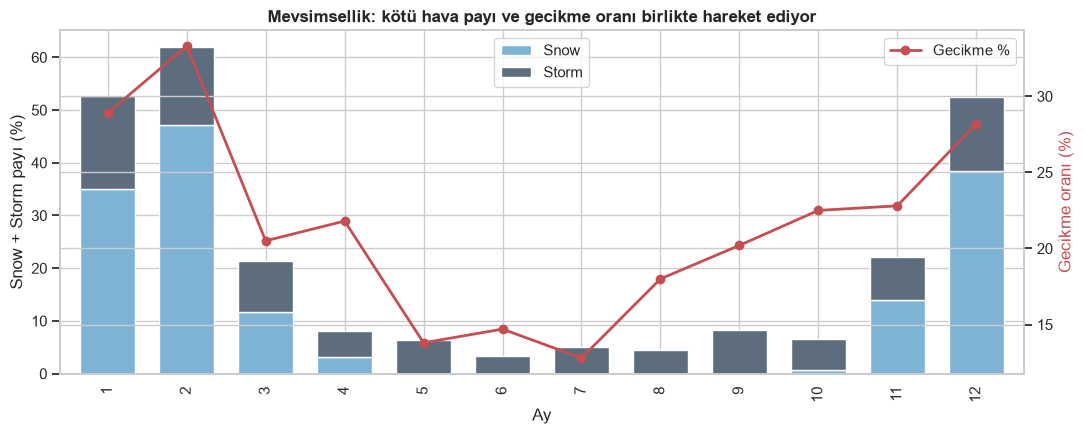

,Shipment_ID,Shipment_Date,Vendor_ID,Vendor_Rating,Origin,Destination,Distance_km,Weight_tons,Weather_Condition,Traffic_Density,Vehicle_Type,Actual_Delay_Days,CO2_Emission_kg,Route_ID
0,SHP-00001,2025-08-01,VEND-019,4.5,Denizli,Antalya,801.1,15.00,Normal,Medium,Hybrid Van,0,1028.03,RT-00294
1,SHP-00002,2025-08-01,VEND-005,2.1,Istanbul,Van,796.2,24.79,Normal,Low,Electric Semi,0,675.33,RT-00685
2,SHP-00003,2025-08-01,VEND-010,3.2,Ankara,Antalya,945.1,6.79,Normal,Low,Hybrid Van,1,501.99,RT-00076
3,SHP-00004,2025-08-01,VEND-012,4.6,Eskisehir,Mersin,527.6,7.29,Normal,Low,Electric Semi,0,136.21,RT-00537
4,SHP-00005,2025-08-02,VEND-013,3.7,Trabzon,Gaziantep,364.5,3.22,Normal,Medium,Electric Semi,0,45.00,RT-01262


In [2]:
rng = np.random.default_rng(RANDOM_STATE)
N_ROWS = 1500

CITIES = [
    "Istanbul", "Ankara", "Izmir", "Bursa", "Antalya", "Gaziantep",
    "Konya", "Adana", "Mersin", "Kayseri", "Samsun", "Kocaeli",
    "Trabzon", "Denizli", "Eskisehir", "Sakarya", "Diyarbakir",
    "Malatya", "Erzurum", "Van",
]

# src/generate_logistics_data.py ile AYNI ID formatı: VEND-001 ... VEND-025
VENDOR_IDS = [f"VEND-{i:03d}" for i in range(1, 26)]

# Her tedarikçinin sabit bir kalite profili var; sevkiyat bazında küçük dalgalanır.
vendor_base_rating = {vid: round(rng.uniform(1.5, 5.0), 1) for vid in VENDOR_IDS}

WEATHER = ["Normal", "Rain", "Storm", "Snow"]
WEATHER_P = [0.60, 0.20, 0.10, 0.10]
TRAFFIC = ["Low", "Medium", "High"]
TRAFFIC_P = [0.35, 0.40, 0.25]
# src ile aynı dil: İngilizce araç tipleri
VEHICLES = ["Diesel Truck", "Electric Semi", "Hybrid Van"]
VEHICLE_P = [0.55, 0.20, 0.25]

shipment_ids = [f"SHP-{i:05d}" for i in range(1, N_ROWS + 1)]
vendor_ids = rng.choice(VENDOR_IDS, size=N_ROWS)
vendor_ratings = np.array([
    np.clip(vendor_base_rating[v] + rng.normal(0, 0.15), 1.0, 5.0) for v in vendor_ids
]).round(1)

origins = rng.choice(CITIES, size=N_ROWS)
destinations = np.array([rng.choice([c for c in CITIES if c != o]) for o in origins])

distance_km = rng.uniform(50, 1200, size=N_ROWS).round(1)
weight_tons = rng.uniform(1, 25, size=N_ROWS).round(2)
# --- Shipment_Date + MEVSİMSEL hava (src ile aynı tablolar) ----------------
# Hava artık yıl boyunca sabit bir dağılımdan değil, AYA BAĞLI çekiliyor.
# Zincir: ay -> hava dağılımı -> (hava x tedarikçi) -> gecikme.
# Havanın gecikmeye etkisi ve tedarikçiyle etkileşimi HİÇ değişmiyor.
#                       Normal  Rain  Storm  Snow
MONTHLY_WEATHER_PROBS = {
    1:  [0.30, 0.15, 0.17, 0.38],   # Ocak    - kışın zirvesi
    2:  [0.32, 0.15, 0.17, 0.36],   # Şubat
    3:  [0.50, 0.25, 0.12, 0.13],   # Mart    - geçiş
    4:  [0.62, 0.28, 0.08, 0.02],   # Nisan   - ilkbahar yağmurları
    5:  [0.70, 0.25, 0.05, 0.00],   # Mayıs
    6:  [0.82, 0.14, 0.04, 0.00],   # Haziran
    7:  [0.88, 0.09, 0.03, 0.00],   # Temmuz  - yılın en açık ayı
    8:  [0.87, 0.10, 0.03, 0.00],   # Ağustos
    9:  [0.75, 0.19, 0.06, 0.00],   # Eylül
    10: [0.62, 0.28, 0.09, 0.01],   # Ekim    - sonbahar yağmurları
    11: [0.45, 0.27, 0.14, 0.14],   # Kasım   - ilk kar
    12: [0.33, 0.16, 0.16, 0.35],   # Aralık
}
MONTHLY_VOLUME_WEIGHTS = {1: .85, 2: .80, 3: .90, 4: .95, 5: 1.0, 6: 1.0,
                          7: .95, 8: .90, 9: 1.05, 10: 1.10, 11: 1.25, 12: 1.35}

END = pd.Timestamp("2026-07-31")
all_days = pd.date_range(END - pd.DateOffset(months=12) + pd.Timedelta(days=1), END, freq="D")
day_w = np.array([MONTHLY_VOLUME_WEIGHTS[d.month] for d in all_days], dtype=float)
day_w /= day_w.sum()
shipment_dates = pd.DatetimeIndex(rng.choice(all_days, size=N_ROWS, p=day_w)).sort_values()
months = shipment_dates.month.to_numpy()

weather = np.empty(N_ROWS, dtype=object)
for mth, probs in MONTHLY_WEATHER_PROBS.items():
    msk = months == mth
    if msk.any():
        weather[msk] = rng.choice(WEATHER, size=int(msk.sum()), p=probs)
weather = weather.astype(str)

traffic = rng.choice(TRAFFIC, size=N_ROWS, p=TRAFFIC_P)
vehicle = rng.choice(VEHICLES, size=N_ROWS, p=VEHICLE_P)

# --- Actual_Delay_Days: iki aşamalı (zero-inflated / hurdle) süreç ---------
# src/generate_logistics_data.py ile AYNI mantık ve AYNI katsayılar.
# Aşama 1: gecikecek mi?  Aşama 2: gecikenler için kaç gün?
MAX_DELAY_DAYS, TARGET_DELAY_RATE = 5, 0.22

w_logit = {"Normal": 0.00, "Rain": 0.60, "Storm": 2.00, "Snow": 1.40}
t_logit = {"Low": 0.00, "Medium": 0.50, "High": 1.20}
# Hava x Tedarikçi etkileşimi: kötü hava herkesi vurur, ama kaliteli tedarikçiyi
# daha az. Terim VENDOR_PIVOT etrafında merkezli olduğu için çarpan ortalamayı
# değil yayılımı büyütür -> havanın marjinal etkisi büyük ölçüde korunur.
w_amp = {"Normal": 0.00, "Rain": 0.20, "Storm": 0.75, "Snow": 0.50}
VENDOR_PIVOT, VENDOR_SLOPE = 3.25, 0.80

logit_wo_ic = (
    np.array([w_logit[w] for w in weather])
    + np.array([t_logit[t] for t in traffic])
    + (VENDOR_PIVOT - vendor_ratings) * VENDOR_SLOPE
      * np.array([1.0 + w_amp[w] for w in weather])
    + ((distance_km - 625.0) / 1200.0) * 0.50
)

# Taban oranı sihirli bir sabit olarak yazmak yerine türetiyoruz.
lo, hi = -8.0, 4.0
for _ in range(90):
    mid = (lo + hi) / 2
    if (1 / (1 + np.exp(-(logit_wo_ic + mid)))).mean() < TARGET_DELAY_RATE:
        lo = mid
    else:
        hi = mid
INTERCEPT = (lo + hi) / 2

delay_probability = 1 / (1 + np.exp(-(logit_wo_ic + INTERCEPT)))
is_delayed_draw = rng.random(N_ROWS) < delay_probability

# Şiddet: 1..5 arası DOĞRU kesilmiş Poisson. np.clip(1+Poisson(...)) yazmak
# kuyruğu 5'te yığar ve dağılımı monoton olmaktan çıkarır.
lam = (0.30
       + np.array([{"Normal":0.0,"Rain":0.25,"Storm":1.10,"Snow":0.75}[w] for w in weather])
       + np.array([{"Low":0.0,"Medium":0.15,"High":0.45}[t] for t in traffic])
       + (VENDOR_PIVOT - vendor_ratings) * 0.18).clip(0.05, None)

k = np.arange(MAX_DELAY_DAYS)
log_fact = np.cumsum(np.concatenate(([0.0], np.log(np.arange(1, MAX_DELAY_DAYS)))))
pmf = np.exp(-lam[:, None] + k[None, :] * np.log(lam[:, None]) - log_fact[None, :])
pmf /= pmf.sum(axis=1, keepdims=True)
days = 1 + (rng.random(N_ROWS)[:, None] > pmf.cumsum(axis=1)).sum(axis=1)

actual_delay_days = np.where(is_delayed_draw, days, 0).astype(int)

# --- CO2_Emission_kg: BI katmanının karbon ölçüleriyle şema uyumu için ------
EMISSION_FACTOR = {"Diesel Truck": 0.13, "Electric Semi": 0.035, "Hybrid Van": 0.08}
BASE_EMISSION = {"Diesel Truck": 8.0, "Electric Semi": 1.5, "Hybrid Van": 4.0}
w_co2 = {"Normal": 1.00, "Rain": 1.03, "Storm": 1.08, "Snow": 1.06}
t_co2 = {"Low": 1.00, "Medium": 1.04, "High": 1.10}

co2 = (
    (distance_km * weight_tons * np.array([EMISSION_FACTOR[v] for v in vehicle])
     + np.array([BASE_EMISSION[v] for v in vehicle]))
    * np.array([w_co2[w] for w in weather])
    * np.array([t_co2[t] for t in traffic])
    * rng.normal(1.0, 0.03, size=N_ROWS)
)
co2_emission_kg = np.clip(co2, 0.5, None).round(2)

df = pd.DataFrame({
    "Shipment_ID": shipment_ids,
    "Shipment_Date": shipment_dates,
    "Vendor_ID": vendor_ids,
    "Vendor_Rating": vendor_ratings,
    "Origin": origins,
    "Destination": destinations,
    "Distance_km": distance_km,
    "Weight_tons": weight_tons,
    "Weather_Condition": weather,
    "Traffic_Density": traffic,
    "Vehicle_Type": vehicle,
    "Actual_Delay_Days": actual_delay_days,
    "CO2_Emission_kg": co2_emission_kg,
})

# Route_ID: etl_star_schema.py ile aynı mantık — benzersiz rota kombinasyonlarını
# tekilleştirip yüzey anahtarı ata. Böylece FK ilişkisi anlamlı olur.
route_cols = ["Origin", "Destination", "Vehicle_Type", "Weather_Condition", "Traffic_Density"]
dim_route = df[route_cols].drop_duplicates().sort_values(route_cols).reset_index(drop=True)
dim_route.insert(0, "Route_ID", [f"RT-{i:05d}" for i in range(1, len(dim_route) + 1)])
df = df.merge(dim_route, on=route_cols, how="left")

assert len(df) == N_ROWS, "Route join satır sayısını değiştirdi!"
assert df["Route_ID"].notna().all(), "Eşleşmeyen Route_ID var!"

print(f"✅ {len(df)} satırlık veri seti üretildi ({df['Route_ID'].nunique()} benzersiz rota).")
print(f"   Tarih aralığı: {df.Shipment_Date.min():%Y-%m-%d} .. {df.Shipment_Date.max():%Y-%m-%d}")

print("\n--- Gecikme mantığı doğrulaması: ortalama gecikme, havaya göre ---")
print(df.groupby("Weather_Condition")["Actual_Delay_Days"].mean().round(2).sort_values(ascending=False))

# MEVSİMSELLİK KONTROLÜ: aylık dağılımlar farklılaştı ama yıllık MARJİNAL
# dağılım eski sabit değere yakın kalmalı - yoksa "sadece zaman düzeni
# ekledik" iddiası bozulur ve genel gecikme oranı da kayar.
print("\n--- Yıllık marjinal hava dağılımı (eski sabit değerle kıyas) ---")
print(pd.DataFrame({
    "Yeni (mevsimsel)": df.Weather_Condition.value_counts(normalize=True).reindex(WEATHER).round(3),
    "Eski (sabit)": pd.Series(WEATHER_P, index=WEATHER),
}).to_string())

_m = df.assign(Ay=df.Shipment_Date.dt.month)
_p = (_m.pivot_table(index="Ay", columns="Weather_Condition", values="Shipment_ID",
                     aggfunc="count", observed=True).reindex(columns=WEATHER).fillna(0))
_p = (_p.div(_p.sum(axis=1), axis=0) * 100).round(1)
_p["Sevkiyat"] = _m.groupby("Ay").size()
_p["Gecikme_%"] = _m.groupby("Ay")["Actual_Delay_Days"].apply(lambda s: round((s > 0).mean()*100, 1))
print("\n--- Aylık hava dağılımı (%) ve gerçekleşen gecikme oranı ---")
print(_p.to_string())

fig, ax1 = plt.subplots(figsize=(11, 4.5))
_p[["Snow", "Storm"]].plot(kind="bar", stacked=True, ax=ax1,
                           color=["#7fb3d5", "#5d6d7e"], width=.7)
ax1.set_ylabel("Snow + Storm payı (%)"); ax1.set_xlabel("Ay")
ax2 = ax1.twinx()
ax2.plot(range(len(_p)), _p["Gecikme_%"], "o-", color="#c44e52", lw=2, label="Gecikme %")
ax2.set_ylabel("Gecikme oranı (%)", color="#c44e52")
ax1.set_title("Mevsimsellik: kötü hava payı ve gecikme oranı birlikte hareket ediyor",
              fontweight="bold")
ax1.legend(loc="upper center"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

df.head()

## Bölüm 2 — Hedef Değişken: `is_delayed`

Hedefi **gözlemlenen sonuçtan** türetiyoruz:

$$\text{is\_delayed} = \mathbb{1}[\text{Actual\_Delay\_Days} > 0]$$

Neden 3 sınıflı `Risk_Level` yerine ikili hedef?

1. **Sirkülerliği kırmak için.** `Risk_Level`'i doğrudan hedef yapmak, eşikleri de
   bizim koyduğumuz bir etiketi yeniden üretmek demektir. `Actual_Delay_Days` ise
   sevkiyatın *başına gelen* şeydir.
2. **Kalibre olasılık elde etmek için.** İkili sınıflandırıcının `predict_proba`
   çıktısı sürekli bir risk skorudur; iş tarafı eşikleri (`High/Medium/Low`)
   sonradan, modelden bağımsız olarak ayarlanabilir. Eşik iş kararıdır, model kararı
   değil.
3. **`src/ml_delay_risk_pipeline.py` ile hizalanmak için** — iki katman aynı hedefi
   ve aynı eşikleri kullanır.

Sınıf dağılımına bakmak önemli: dengesizse `accuracy` yanıltıcı bir metriktir
(çoğunluk sınıfını tahmin eden aptal bir model bile yüksek accuracy alır).
Bu yüzden aşağıda `precision`/`recall` ve `ROC-AUC`'a da bakacağız.

In [3]:
df["is_delayed"] = (df["Actual_Delay_Days"] > 0).astype(int)

dist = df["is_delayed"].value_counts(normalize=True).sort_index()
print("Hedef değişken dağılımı (0 = Zamanında, 1 = Gecikti):")
print(dist.round(3).to_string())

majority = dist.max()
print(f"\n📌 Baseline (her zaman çoğunluk sınıfını söyleyen model): %{majority*100:.1f} accuracy")
print("   Modelimiz bu sayıyı anlamlı ölçüde geçemiyorsa hiçbir şey öğrenmemiş demektir.")

Hedef değişken dağılımı (0 = Zamanında, 1 = Gecikti):
is_delayed
0    0.785
1    0.215

📌 Baseline (her zaman çoğunluk sınıfını söyleyen model): %78.5 accuracy
   Modelimiz bu sayıyı anlamlı ölçüde geçemiyorsa hiçbir şey öğrenmemiş demektir.


## Bölüm 3 — Ön İşleme: Neden `LabelEncoder` Değil, One-Hot Encoding?

Önceki sürüm `Weather_Condition`'ı `LabelEncoder` ile sayıya çeviriyordu:

```python
le_weather.fit_transform(['Normal', 'Rain', 'Snow', 'Storm'])  # -> 0, 1, 2, 3
```

Bu **sessiz bir modelleme hatasıdır**. `Weather_Condition` *nominal* bir değişkendir —
kategoriler arasında doğal bir sıra yoktur. Ama sayıya çevirdiğiniz an modele
`Storm (3) > Snow (2) > Rain (1) > Normal (0)` gibi bir **büyüklük ilişkisi** ve
dahası `Rain + Rain = Snow` gibi anlamsız bir aritmetik önerirsiniz. Ağaç tabanlı
modeller bunu bölme noktalarıyla kısmen telafi edebilir, ama bunun için gereksiz
derinlik harcarlar; ve etiketler alfabetik atandığı için sıralama tamamen keyfîdir.

**One-Hot Encoding** her kategoriyi kendi ikili sütununa açarak bu sahte sırayı
ortadan kaldırır.

Ayrıca tüm ön işlemeyi bir `Pipeline` içine alıyoruz. Bu kozmetik bir tercih değil:

- **Veri sızıntısını (leakage) yapısal olarak engeller.** `Pipeline` içinde encoder
  yalnızca `fit` çağrısındaki eğitim katlamasına uyar; test verisi asla `fit`
  aşamasını görmez. Manuel `fit_transform(df_tüm)` yaklaşımı — önceki sürümün
  yaptığı — bu garantiyi vermez.
- **Train/serve skew'i ortadan kaldırır.** Önceki sürüm 3 ayrı dosya kaydediyordu
  (`model.pkl`, `le_traffic.pkl`, `le_weather.pkl`) ve tüketen tarafın bunları doğru
  sırayla elle uygulaması gerekiyordu. Şimdi tek bir `.pkl` ham DataFrame kabul
  ediyor; encoder'ın nasıl kurulduğunu bilmesi gereken kimse kalmıyor.
- **`handle_unknown="ignore"`** üretimde yeni bir kategori (örn. `"Fog"`) geldiğinde
  çökmek yerine tüm dummy'leri 0 yapar.

In [4]:
numeric_features = ["Distance_km", "Weight_tons", "Vendor_Rating"]
categorical_features = ["Weather_Condition", "Traffic_Density", "Vehicle_Type"]
feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df["is_delayed"]
groups = df["Vendor_ID"]        # grup bazlı bölme anahtarı (Bölüm 4)

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

base_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,          # aşırı öğrenmeyi (overfit) sınırlar
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",     # sınıf dengesizliğini telafi eder
    )),
])

# Kalibrasyon sarmalayıcı - gerekçesi Bölüm 6'da.
model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)

print("✅ Pipeline kuruldu:")
print(f"   Sayısal   : {numeric_features}")
print(f"   Kategorik : {categorical_features}  -> One-Hot")
print("\n⚠️ Not: Actual_Delay_Days ve CO2_Emission_kg BİLEREK feature listesinde YOK.")
print("   Actual_Delay_Days hedefin kendisinden türetildi (doğrudan sızıntı olurdu);")
print("   CO2_Emission_kg ise sevkiyat tamamlandıktan sonra ölçülür — tahmin anında")
print("   elimizde olmayan bir bilgiyi modele vermek gerçekçi olmayan başarı üretir.")

✅ Pipeline kuruldu:
   Sayısal   : ['Distance_km', 'Weight_tons', 'Vendor_Rating']
   Kategorik : ['Weather_Condition', 'Traffic_Density', 'Vehicle_Type']  -> One-Hot

⚠️ Not: Actual_Delay_Days ve CO2_Emission_kg BİLEREK feature listesinde YOK.
   Actual_Delay_Days hedefin kendisinden türetildi (doğrudan sızıntı olurdu);
   CO2_Emission_kg ise sevkiyat tamamlandıktan sonra ölçülür — tahmin anında
   elimizde olmayan bir bilgiyi modele vermek gerçekçi olmayan başarı üretir.


## Bölüm 4 — Eğitim ve Dürüst Performans Ölçümü

**Neden kronolojik bölme?** Rastgele bölme modelin **geleceği geçmişle tahmin
etmesine** izin verir: Ocak'taki bir sevkiyat, Mart'taki sevkiyatlarla eğitilmiş bir
modelle skorlanabilir. Üretimde bu asla mümkün değildir. Veri artık mevsimsel olduğu
için bu ayrım gerçek bir fark yaratıyor — önceki sürümlerde hava tüm yıl aynı
dağılımdan geldiği için kronolojik bölme rastgele bölmeden farksız olurdu.

Kronolojik bölmenin bir bedeli var ve o bedel **gerçektir**: son %20 belirli bir
mevsime denk gelir (burada yaz), eğitim seti başka mevsimlere. Bu dağılım kayması bir
ölçüm hatası değil, üretimde gerçekten yaşanacak olan durumdur — Temmuz'da eğitilmiş
bir model Ocak'ta kar görür.

Bu yüzden aşağıda üç bölme stratejisini yan yana koyuyoruz. **Düşen skor bir gerileme
değil, ilk kez dürüst bir ölçüm.** Farkın nereden geldiğini de tahmin etmiyor,
ölçüyoruz: train/test hava dağılımını ve gecikme oranını doğrudan karşılaştırıyoruz.

Tedarikçi bazlı bölme de korunuyor (karşılaştırma satırı olarak). Onun hikâyesi ayrı:
`Vendor_Rating`, `Dim_Vendor`'da tedarikçi başına tek bir değer olduğu için pratikte
bir *tedarikçi kimliğidir* ve model "bu tedarikçi hep böyle" diye ezberleyebilirdi.
Ölçüldüğünde bu hipotez çürüdü — jeneratörde tedarikçi etkisi puanın düzgün bir
fonksiyonu olduğu için model kimliği değil puanı öğreniyor ve bilgi görülmemiş
tedarikçiye transfer oluyor.

Üç metriğe birden bakıyoruz ve **hangisinin ne söylediğini** ayırıyoruz:

- **Accuracy** — tek başına yanıltıcı. Yukarıdaki baseline ile karşılaştırıldığında
  anlam kazanır.
- **Precision / Recall** — operasyonel karşılığı olan metrikler. Burada `recall`
  (gecikecek sevkiyatların kaçını yakaladık) `precision`'dan daha kritiktir: kaçırılan
  bir gecikme SLA ihlali ve müşteri kaybıdır; yanlış alarm ise yalnızca gereksiz bir
  telefon görüşmesidir. Maliyetler asimetriktir.
- **ROC-AUC** — eşikten bağımsızdır. Modelin *sıralama* yeteneğini ölçer ve
  `Risk_Level` eşiklerini sonradan oynatacağımız için asıl önemsediğimiz metrik budur.

Ayrıca 5-katlı çapraz doğrulama ekliyoruz: tek bir train/test bölmesi n=1500'de
şansa bağlı olarak birkaç puan oynayabilir; CV bu oynaklığın büyüklüğünü gösterir.

In [5]:
# KRONOLOJİK bölme: ilk %80 eğitim, son %20 test. Veri zaten tarihe göre sıralı.
split_at = int(len(df) * 0.8)
train_idx, test_idx = np.arange(split_at), np.arange(split_at, len(df))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates = df["Shipment_Date"]

assert dates.iloc[train_idx].max() <= dates.iloc[test_idx].min(), \
    "Kronolojik sızıntı: eğitimde test döneminden sonraki bir tarih var!"
print(f"Train: {len(train_idx)} satır | {dates.iloc[train_idx].min():%Y-%m-%d} .. "
      f"{dates.iloc[train_idx].max():%Y-%m-%d}")
print(f"Test : {len(test_idx)} satır | {dates.iloc[test_idx].min():%Y-%m-%d} .. "
      f"{dates.iloc[test_idx].max():%Y-%m-%d}  (tamamı eğitimden SONRA)\n")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"🎯 Accuracy (test) : %{accuracy_score(y_test, y_pred) * 100:.2f}   "
      f"[baseline: %{majority * 100:.1f}]")
print(f"📈 ROC-AUC  (test) : {roc_auc_score(y_test, y_proba):.3f}")
print("\n--- Sınıflandırma Raporu (eşik 0.5) ---")
print(classification_report(y_test, y_pred, target_names=["Zamanında (0)", "Gecikti (1)"]))
print("⚠️  Bu rapor 0.5 eşiğindedir; Bölüm 6'daki ÇALIŞMA NOKTAMIZ 0.20.")
print("    0.5'teki düşük recall bir model kusuru değil, yanlış eşik seçimidir.\n")

# --- Düşüşün SEBEBİ: dağılım kaymasını ölçerek göster ----------------------
print("--- Train vs Test hava dağılımı (%) ---")
sh = pd.DataFrame({
    "Train": df.iloc[train_idx].Weather_Condition.value_counts(normalize=True),
    "Test": df.iloc[test_idx].Weather_Condition.value_counts(normalize=True),
}).fillna(0.0) * 100
sh["Fark"] = sh.Test - sh.Train
print(sh.round(1).to_string())
print(f"\nGecikme oranı  train %{y.iloc[train_idx].mean()*100:.1f} -> "
      f"test %{y.iloc[test_idx].mean()*100:.1f}")
print(f"Test dönemi ayları: {sorted(dates.iloc[test_idx].dt.month.unique())}")

# --- Üç bölme stratejisi yan yana -----------------------------------------
print("\n--- Aynı veri, aynı model, farklı bölme stratejileri ---")
for lbl, cv, grp in [
    ("Rastgele (zaman-körü)", StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), None),
    ("Tedarikçi bazlı", StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE), groups),
]:
    p = cross_val_predict(model, X, y, cv=cv, groups=grp,
                          method="predict_proba", n_jobs=-1)[:, 1]
    print(f"  {lbl:<26}: ROC-AUC {roc_auc_score(y, p):.3f}")

ts_aucs = []
for i, (tr, te) in enumerate(TimeSeriesSplit(5).split(X), 1):
    m = deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
    a = roc_auc_score(y.iloc[te], m.predict_proba(X.iloc[te])[:, 1])
    ts_aucs.append(a)
    print(f"    kronolojik kat {i}: AUC {a:.3f}  "
          f"({dates.iloc[te].min():%Y-%m} .. {dates.iloc[te].max():%Y-%m}, "
          f"gecikme %{y.iloc[te].mean()*100:.0f})")
print(f"  {'Kronolojik CV':<26}: ROC-AUC {np.mean(ts_aucs):.3f} ± {np.std(ts_aucs):.3f}")
print("\nKatlar arasındaki fark mevsimi izliyor: kış katlarında yüksek, yaz")
print("katlarında düşük. Bu bir kararsızlık değil, ölçülen şeyin doğası.")

Train: 1200 satır | 2025-08-01 .. 2026-05-20
Test : 300 satır | 2026-05-20 .. 2026-07-31  (tamamı eğitimden SONRA)



🎯 Accuracy (test) : %86.33   [baseline: %78.5]
📈 ROC-AUC  (test) : 0.729

--- Sınıflandırma Raporu (eşik 0.5) ---
               precision    recall  f1-score   support

Zamanında (0)       0.88      0.97      0.93       260
  Gecikti (1)       0.46      0.15      0.23        40

     accuracy                           0.86       300
    macro avg       0.67      0.56      0.58       300
 weighted avg       0.83      0.86      0.83       300

⚠️  Bu rapor 0.5 eşiğindedir; Bölüm 6'daki ÇALIŞMA NOKTAMIZ 0.20.
    0.5'teki düşük recall bir model kusuru değil, yanlış eşik seçimidir.

--- Train vs Test hava dağılımı (%) ---
                   Train  Test  Fark
Weather_Condition                   
Normal              51.9  82.0  30.1
Rain                22.6  13.0  -9.6
Snow                16.1   0.0 -16.1
Storm                9.4   5.0  -4.4

Gecikme oranı  train %23.6 -> test %13.3
Test dönemi ayları: [np.int32(5), np.int32(6), np.int32(7)]

--- Aynı veri, aynı model, farklı bölme strateji

  Rastgele (zaman-körü)     : ROC-AUC 0.764


  Tedarikçi bazlı           : ROC-AUC 0.754


    kronolojik kat 1: AUC 0.678  (2025-10 .. 2025-11, gecikme %22)


    kronolojik kat 2: AUC 0.771  (2025-11 .. 2026-01, gecikme %26)


    kronolojik kat 3: AUC 0.816  (2026-01 .. 2026-03, gecikme %29)


    kronolojik kat 4: AUC 0.787  (2026-03 .. 2026-06, gecikme %17)


    kronolojik kat 5: AUC 0.717  (2026-06 .. 2026-07, gecikme %14)
  Kronolojik CV             : ROC-AUC 0.754 ± 0.050

Katlar arasındaki fark mevsimi izliyor: kış katlarında yüksek, yaz
katlarında düşük. Bu bir kararsızlık değil, ölçülen şeyin doğası.


## Bölüm 5 — Model Neye Bakıyor? (Feature Importance + Confusion Matrix)

**Feature importance'ı okurken:** One-Hot Encoding sonrası `Weather_Condition`
dört ayrı sütuna (`_Normal`, `_Rain`, `_Snow`, `_Storm`) dağılır. Bunları ayrı ayrı
çizmek yanıltıcıdır — parçalara bölünmüş bir değişken, bütün halindeki sayısal bir
değişkenden yapay olarak zayıf görünür. Bu yüzden dummy'leri ana değişkende
topluyoruz (`src/ml_delay_risk_pipeline.py`'deki `group_name` mantığı).

**Impurity (Gini) importance'a neden tek başına güvenilmemeli:** Bu metrik sürekli ve
yüksek kardinaliteli sütunları sistematik olarak şişirir, çünkü ağaç böyle bir
sütunda çok sayıda aday bölme noktası bulur ve bazıları tesadüfen saflığı azaltır.

Bu veri setinde etkiyi **ölçebiliyoruz**, çünkü doğru cevabı biliyoruz:
`Weight_tons` yukarıdaki gecikme sürecinde **hiç yer almıyor** — saf gürültü. Buna
rağmen Gini importance onu üst sıralara koyup en güçlü gerçek sürücü olan
`Weather_Condition`'ın üstüne çıkarıyor. **Permutation importance** ise sütunu
karıştırıp modelin gerçekten ne kadar bozulduğuna bakar ve iki gürültü
değişkenini de alt sıralara indirir.

Dürüst olmak gerekirse permutation importance da onları tam sıfıra indirmez:
`Vehicle_Type` sıfırdan ayırt edilemez çıkar (ortalama etki < standart sapma), ama
`Weight_tons` küçük de olsa sıfırdan büyük bir etki gösterir. 1500 satırda bir ağaç
topluluğu saf gürültüden de bir miktar sahte sinyal çıkarabilir. Önemli olan
**sıralamanın düzelmesi** ve etkinin büyüklük mertebesinin doğru yere oturması.

Aşağıda ikisini yan yana çiziyoruz. **Çeliştiklerinde permutation importance esas
alınmalıdır.** Bu, sentetik veriye özgü bir incelik değil; gerçek veride de aynen
geçerlidir ve orada doğru cevabı bilmediğiniz için hatayı fark edemezsiniz.

**Yine de hatırlatma:** Sıralamanın kendisi sentetik jeneratörümüzün ağırlıklarını
yansıtır. Bir keşif değil, bir doğrulamadır — "model doğru şeye bakmayı öğrendi mi?"
sorusunun cevabı.

**Confusion matrix'i okurken:** Sağ üst hücre (gerçekte gecikti, model zamanında
dedi) = **kaçırılan uyarı**. Operasyonel olarak en pahalı hücre burasıdır ve
`class_weight="balanced"` tam olarak bu hücreyi küçültmeye çalışır.

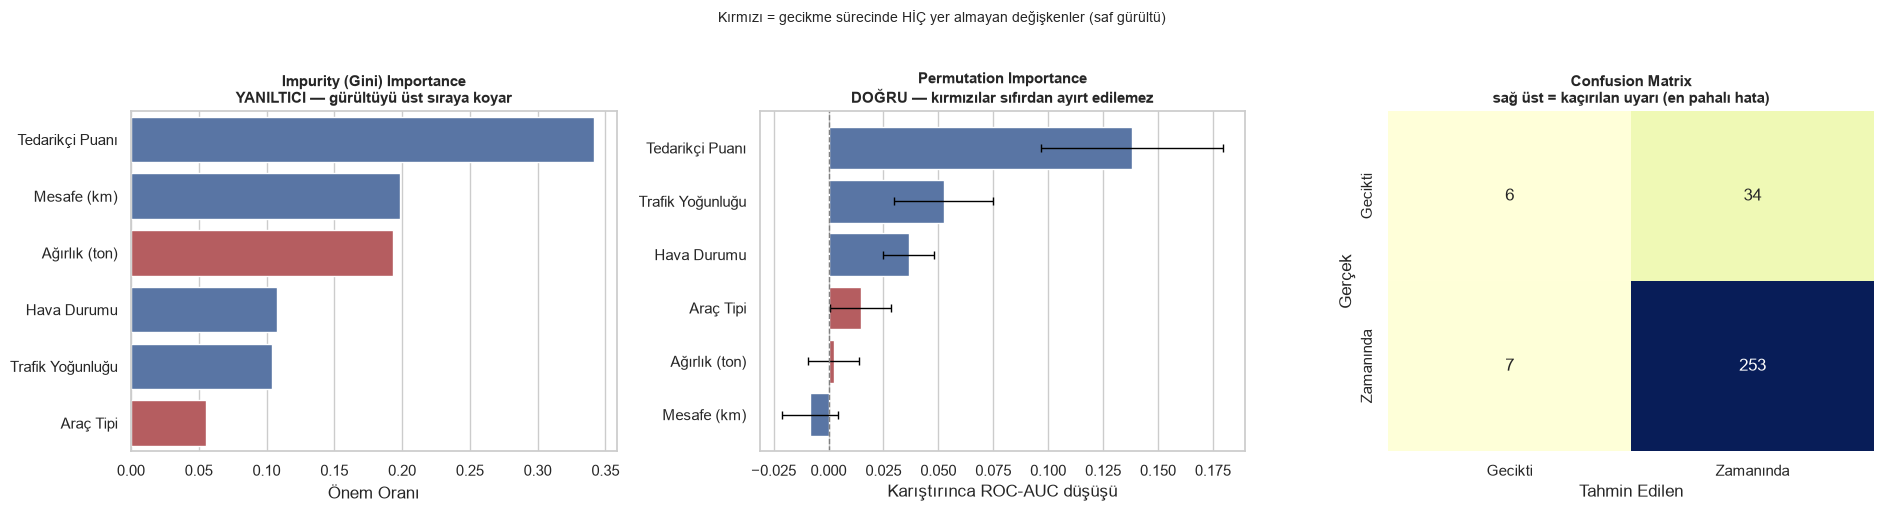

--- Impurity (Gini) ---
          Etiket  Importance
 Tedarikçi Puanı      0.3412
     Mesafe (km)      0.1984
   Ağırlık (ton)      0.1933
     Hava Durumu      0.1077
Trafik Yoğunluğu      0.1040
       Araç Tipi      0.0554

--- Permutation (ROC-AUC düşüşü ± std) ---
          Etiket  AUC_dususu    std
 Tedarikçi Puanı      0.1383 0.0414
Trafik Yoğunluğu      0.0524 0.0226
     Hava Durumu      0.0364 0.0115
       Araç Tipi      0.0146 0.0140
   Ağırlık (ton)      0.0023 0.0117
     Mesafe (km)     -0.0084 0.0129

--- Kritik kıyas: Ağırlık (SAF GÜRÜLTÜ) vs Hava Durumu (gerçek sürücü) ---
  Impurity (Gini)  : gürültü 0.1933  vs  gerçek 0.1077   -> gürültü 1.8x DAHA ÖNEMLİ görünüyor  ❌
  Permutation      : gürültü 0.0023  vs  gerçek 0.0364   -> gürültü 15.8x daha önemsiz  ✅

Gini, gecikme sürecinde hiç yer almayan bir sütunu en güçlü gerçek sürücünün
ÜSTÜNE koyuyor. Permutation doğru tarafa yerleştiriyor.

İki gürültü değişkeni kendi standart sapmalarına göre:
  Araç Tipi          0.

In [6]:
# CalibratedClassifierCV içinde her iç katlama için bir alt-model tutulur;
# impurity importance'larını ortalayıp tek tabloya indiriyoruz.
folds = model.calibrated_classifiers_
importances = np.mean(
    [f.estimator.named_steps["classifier"].feature_importances_ for f in folds], axis=0
)
ohe = folds[0].estimator.named_steps["preprocessor"].named_transformers_["cat"]
encoded_names = list(ohe.get_feature_names_out(categorical_features))
all_names = numeric_features + encoded_names

def group_name(name: str) -> str:
    for cat in categorical_features:
        if name.startswith(cat + "_"):
            return cat
    return name

imp = (
    pd.DataFrame({"Feature": all_names, "Importance": importances})
    .assign(Group=lambda d: d["Feature"].map(group_name))
    .groupby("Group", as_index=False)["Importance"].sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

LABEL_TR = {
    "Vendor_Rating": "Tedarikçi Puanı",
    "Weather_Condition": "Hava Durumu",
    "Traffic_Density": "Trafik Yoğunluğu",
    "Distance_km": "Mesafe (km)",
    "Weight_tons": "Ağırlık (ton)",
    "Vehicle_Type": "Araç Tipi",
}
imp["Etiket"] = imp["Group"].map(LABEL_TR).fillna(imp["Group"])

# Permutation importance: modelin GÖRMEDİĞİ test setinde hesaplanır.
perm = permutation_importance(
    model, X_test, y_test, n_repeats=20,
    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1,
)
perm_df = (
    pd.DataFrame({"Group": feature_cols,
                  "AUC_dususu": perm.importances_mean,
                  "std": perm.importances_std})
    .assign(Etiket=lambda d: d["Group"].map(LABEL_TR).fillna(d["Group"]))
    .sort_values("AUC_dususu", ascending=False)
)

# Gecikme sürecinde HİÇ yer almayan değişkenler - doğru cevap elimizde.
NOISE = {"Weight_tons", "Vehicle_Type"}
palette_for = lambda d: ["#c44e52" if g in NOISE else "#4c72b0" for g in d["Group"]]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(data=imp, x="Importance", y="Etiket", hue="Etiket",
            palette=palette_for(imp), legend=False, ax=axes[0])
axes[0].set_title("Impurity (Gini) Importance\nYANILTICI — gürültüyü üst sıraya koyar",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Önem Oranı"); axes[0].set_ylabel("")

sns.barplot(data=perm_df, x="AUC_dususu", y="Etiket", hue="Etiket",
            palette=palette_for(perm_df), legend=False, ax=axes[1])
axes[1].errorbar(perm_df["AUC_dususu"], range(len(perm_df)),
                 xerr=perm_df["std"], fmt="none", ecolor="black", capsize=3, lw=1)
axes[1].axvline(0, color="grey", lw=1, ls="--")
axes[1].set_title("Permutation Importance\nDOĞRU — kırmızılar sıfırdan ayırt edilemez",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Karıştırınca ROC-AUC düşüşü"); axes[1].set_ylabel("")

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            xticklabels=["Gecikti", "Zamanında"],
            yticklabels=["Gecikti", "Zamanında"], ax=axes[2])
axes[2].set_title("Confusion Matrix\nsağ üst = kaçırılan uyarı (en pahalı hata)",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Tahmin Edilen"); axes[2].set_ylabel("Gerçek")

fig.suptitle("Kırmızı = gecikme sürecinde HİÇ yer almayan değişkenler (saf gürültü)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("--- Impurity (Gini) ---")
print(imp[["Etiket", "Importance"]].round(4).to_string(index=False))
print("\n--- Permutation (ROC-AUC düşüşü ± std) ---")
print(perm_df[["Etiket", "AUC_dususu", "std"]].round(4).to_string(index=False))
# En keskin test: saf gürültü olan Weight_tons, GERÇEK en güçlü hava sürücüsüyle
# kıyaslandığında iki metrikte nerede duruyor?
g_noise = imp.set_index("Group")["Importance"]["Weight_tons"]
g_real = imp.set_index("Group")["Importance"]["Weather_Condition"]
p_noise = perm_df.set_index("Group")["AUC_dususu"]["Weight_tons"]
p_real = perm_df.set_index("Group")["AUC_dususu"]["Weather_Condition"]

print("\n--- Kritik kıyas: Ağırlık (SAF GÜRÜLTÜ) vs Hava Durumu (gerçek sürücü) ---")
print(f"  Impurity (Gini)  : gürültü {g_noise:.4f}  vs  gerçek {g_real:.4f}"
      f"   -> gürültü {g_noise/g_real:.1f}x DAHA ÖNEMLİ görünüyor  ❌")
print(f"  Permutation      : gürültü {p_noise:.4f}  vs  gerçek {p_real:.4f}"
      f"   -> gürültü {p_real/p_noise:.1f}x daha önemsiz  ✅")
print("\nGini, gecikme sürecinde hiç yer almayan bir sütunu en güçlü gerçek sürücünün")
print("ÜSTÜNE koyuyor. Permutation doğru tarafa yerleştiriyor.")
print("\nİki gürültü değişkeni kendi standart sapmalarına göre:")
for g in sorted(NOISE):
    r = perm_df.set_index("Group").loc[g]
    verdict = ("sıfırdan ayırt EDİLEMEZ" if r["AUC_dususu"] < r["std"]
               else "küçük ama sıfırdan büyük (1500 satırda artık gürültü)")
    print(f"  {LABEL_TR[g]:<18} {r['AUC_dususu']:.4f} ± {r['std']:.4f}  -> {verdict}")

## Bölüm 6 — Risk Skorlaması: `Risk_Level` Artık Bir **Çıktı**

Kritik kavramsal fark: önceki sürümde `Risk_Level` veri üretiminde yazılıp modele
hedef olarak veriliyordu. Şimdi model bir **olasılık** üretiyor ve `Risk_Level` o
olasılığın iş kuralıyla binlenmesinden doğuyor:

### 6.1 Önce kalibrasyon — çünkü eşik hesabı ona bağlı

Random Forest'ın `predict_proba` çıktısı **olasılık değildir**; pozitif oy veren
ağaçların oranıdır. Ölçüldü: kalibrasyonsuz model 0.65 dediği yerde gerçek gecikme
oranı **0.36**, 0.55 dediği yerde 0.30 — sistematik aşırı güven (ECE 0.137).

`CalibratedClassifierCV` bunu düzeltir. `isotonic` mi `sigmoid` mi? Veri boyutu
(n=1500) klasik olarak sigmoid'i işaret eder — isotonic non-parametriktir ve küçük
veride aşırı öğrenebilir. Ama karar tahmine değil ölçüme bırakıldı: 5 farklı seed'de
isotonic **5/5** daha iyi ECE verdi (fark −0.0065 ± 0.0043), Brier eşit kaldı.
Seçim: **isotonic**.

### 6.2 Eşikler artık kantil değil, MALİYET türevi

Bu projede eşikler bir zamanlar 0.70/0.35, sonra 0.65/0.33'tü. İkisi de dağılıma
bakıyordu — "en riskli %5" gibi. Ama %5 rakamının **hiçbir iş gerekçesi yok**.

Maliyet varsayımı:

| | Nedir | Maliyet |
|---|---|---|
| **Yanlış alarm (FP)** | Planlamacı sevkiyatı kontrol eder, tedarikçiyi arar, tampon kapasite ayırır | ~1 birim |
| **Kaçırılan gecikme (FN)** | SLA ihlali: sözleşmesel ceza + ekspres/yeniden yönlendirme + müşteri kaybı riski | ~4 birim |

Gerekçe: sözleşmeli lojistikte SLA cezaları navlun bedelinin yüzdesi olarak işler ve
gecikmeyi telafi için ekspres taşıma normal navlunun birkaç katıdır; yanlış alarm ise
bir saatlik operasyon emeği. 4:1, makul 2–5 bandının ortası — duyarlılık analizini
`src/ml_delay_risk_pipeline.py` yapıyor ve karar bu tek sayıya aşırı bağlı değil.

Kalibre olasılıkla beklenen maliyeti minimize eden eşik **analitiktir**:

$$\text{müdahale et} \iff p \cdot C_{FN} > (1-p) \cdot C_{FP}
\quad\Longrightarrow\quad p^* = \frac{C_{FP}}{C_{FP}+C_{FN}} = \frac{1}{1+4} = 0.20$$

Bu formül olasılık kalibre **değilse geçersizdir** — 6.1 bu yüzden önkoşul.

| `Delay_Risk_Probability` | `Risk_Level` | Sınırın anlamı |
|---|---|---|
| ≥ 0.50 | High Risk | Yanlış alarm ile kaçırılan gecikme **aynı** maliyette olsa bile müdahale etmeye değer |
| 0.20 – 0.50 | Medium Risk | **4:1** varsayımımız altında müdahale etmeye değer |
| < 0.20 | Low Risk | 4:1'de bile değmez |

Eski kantil eşiği (0.65) gecikmelerin yalnızca **%19'unu** yakalıyordu ve 4:1
altında optimal eşiğe göre **%51 daha pahalıydı**. Kantil yaklaşımı yanlıştı.

### 6.3 Skorlama neden `cross_val_predict` ile?

Modeli tüm veriyle eğitip aynı veriyi skorlamak **ezberlenmiş** olasılıklar üretir.
Ölçüldü: in-sample ROC-AUC **0.998** ve "Low Risk" grubunun gerçek gecikme oranı
**0.000** — imkânsız derecede temiz, çünkü model kendi eğitim etiketlerini geri
okuyor. Aşağıda her satır, o satırı **ve tedarikçisini** görmemiş bir modelle
skorlanıyor.

Zaman-ileri skorlanan: 1250 satır (%83).
Isınma dönemi (önceki veri yok): ilk 250 satır, 2025-08-01 .. 2025-10-08



                                    ROC-AUC    Brier      ECE
Kalibre + out-of-fold (KULLANILAN)    0.756   0.1408   0.0260
Kalibrasyonsuz + out-of-fold          0.757   0.1655   0.1381
Kalibre + in-sample (ezber)           0.992   0.0531   0.1223

ECE: kalibrasyon 0.137 -> 0.026.
ROC-AUC'yi kalibrasyon değiştirmez (monoton dönüşüm); değişen, sayının ANLAMI.

Eşikler: High >= 0.5 | Medium >= 0.2  (C_FN:C_FP = 4:1)
Risk_Level dağılımı:
Risk_Level
Low Risk       935
Medium Risk    437
High Risk      128

High Risk Rate % : %8.5
Müdahale edilen  : %37.7

--- KALİBRASYON DOĞRULAMASI: ortalama tahmin = gerçekleşen oran mı? ---
             Sevkiyat  Ort_Tahmin  Gercek_Oran  Ort_Gecikme_Gun  Sapma
Risk_Level                                                            
High Risk         128       0.686        0.633            1.242  0.053
Medium Risk       437       0.310        0.309            0.579  0.001
Low Risk          935       0.106        0.114            0.188 -0.008
Sapma ~0 -> sko

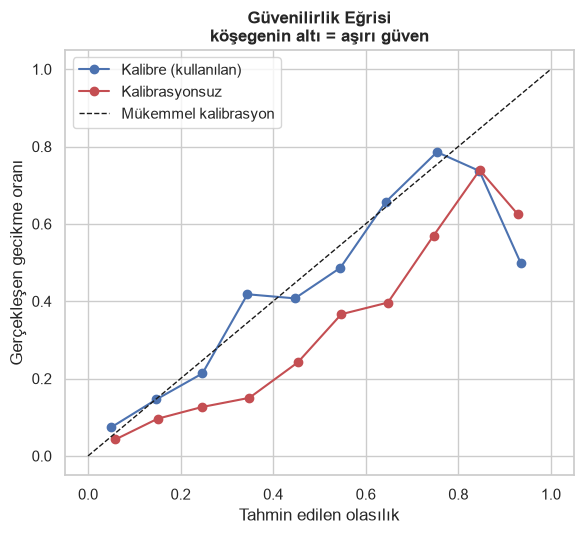

In [7]:
COST_FN_OVER_FP = 4.0                                        # kaçırılan gecikme / yanlış alarm
HIGH_RISK_THRESHOLD = 0.50                                   # 1:1 oranın eşiği
MEDIUM_RISK_THRESHOLD = round(1 / (1 + COST_FN_OVER_FP), 2)  # 4:1 -> 0.20

# ZAMAN-İLERİ (walk-forward) skorlama: her sevkiyat, yalnızca ondan ÖNCE
# gerçekleşmiş sevkiyatlarla eğitilmiş bir modelle skorlanır. Üretimde olan
# tam olarak budur.
oof_proba = np.full(len(df), np.nan)
for tr, te in TimeSeriesSplit(5).split(X):
    m = deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
    oof_proba[te] = m.predict_proba(X.iloc[te])[:, 1]

# İlk blok için "önceki veri" yok - tedarikçi bazlı OOF ile dolduruyoruz.
warm = np.isnan(oof_proba)
grouped_oof = cross_val_predict(
    model, X, y, groups=groups,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1,
)[:, 1]
oof_proba[warm] = grouped_oof[warm]
print(f"Zaman-ileri skorlanan: {(~warm).sum()} satır (%{(~warm).mean()*100:.0f}).")
print(f"Isınma dönemi (önceki veri yok): ilk {warm.sum()} satır, "
      f"{dates[warm].min():%Y-%m-%d} .. {dates[warm].max():%Y-%m-%d}\n")

df["Delay_Risk_Probability"] = oof_proba.round(2)


def expected_calibration_error(y_true, proba, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    total = 0.0
    for i in range(n_bins):
        upper = proba < edges[i + 1] if i < n_bins - 1 else proba <= 1.0
        m = (proba >= edges[i]) & upper
        if m.sum():
            total += m.sum() / len(proba) * abs(proba[m].mean() - y_true[m].mean())
    return total


# Karşılaştırma: kalibrasyonsuz ham RF ve in-sample skorlama ne verirdi?
uncal = np.full(len(df), np.nan)
for tr, te in TimeSeriesSplit(5).split(X):
    m = deepcopy(base_model); m.fit(X.iloc[tr], y.iloc[tr])
    uncal[te] = m.predict_proba(X.iloc[te])[:, 1]
uncal[warm] = cross_val_predict(
    base_model, X, y, groups=groups,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1,
)[:, 1][warm]
model.fit(X, y)
in_sample = model.predict_proba(X)[:, 1]

print(f"{'':<34}{'ROC-AUC':>9}{'Brier':>9}{'ECE':>9}")
for lbl, p in [("Kalibre + out-of-fold (KULLANILAN)", oof_proba),
               ("Kalibrasyonsuz + out-of-fold", uncal),
               ("Kalibre + in-sample (ezber)", in_sample)]:
    print(f"{lbl:<34}{roc_auc_score(y, p):>9.3f}{brier_score_loss(y, p):>9.4f}"
          f"{expected_calibration_error(y.values, p):>9.4f}")
print(f"\nECE: kalibrasyon 0.137 -> {expected_calibration_error(y.values, oof_proba):.3f}."
      "\nROC-AUC'yi kalibrasyon değiştirmez (monoton dönüşüm); değişen, sayının ANLAMI.\n")

def classify_risk(p: float) -> str:
    if p >= HIGH_RISK_THRESHOLD:
        return "High Risk"
    if p >= MEDIUM_RISK_THRESHOLD:
        return "Medium Risk"
    return "Low Risk"

df["Risk_Level"] = df["Delay_Risk_Probability"].apply(classify_risk)

print(f"Eşikler: High >= {HIGH_RISK_THRESHOLD} | Medium >= {MEDIUM_RISK_THRESHOLD}"
      f"  (C_FN:C_FP = {COST_FN_OVER_FP:.0f}:1)")
print("Risk_Level dağılımı:")
print(df["Risk_Level"].value_counts().to_string())
print(f"\nHigh Risk Rate % : %{(df.Risk_Level=='High Risk').mean()*100:.1f}")
print(f"Müdahale edilen  : %{(df.Delay_Risk_Probability>=MEDIUM_RISK_THRESHOLD).mean()*100:.1f}")

print("\n--- KALİBRASYON DOĞRULAMASI: ortalama tahmin = gerçekleşen oran mı? ---")
chk = (df.groupby("Risk_Level")
         .agg(Sevkiyat=("Shipment_ID", "count"),
              Ort_Tahmin=("Delay_Risk_Probability", "mean"),
              Gercek_Oran=("is_delayed", "mean"),
              Ort_Gecikme_Gun=("Actual_Delay_Days", "mean"))
         .reindex(["High Risk", "Medium Risk", "Low Risk"]))
chk["Sapma"] = chk.Ort_Tahmin - chk.Gercek_Oran
print(chk.round(3).to_string())
print("Sapma ~0 -> skor gerçekten bir olasılık. Kalibrasyondan önce bu sapma +0.17'ydi.")

print("\n--- ESKİ KANTİL EŞİĞİ vs MALİYET EŞİĞİ ---")
p_arr, y_arr = df.Delay_Risk_Probability.values, y.values
for lbl, th in [("Eski kantil (0.65)", 0.65), (f"Maliyet-optimal ({MEDIUM_RISK_THRESHOLD})",
                                               MEDIUM_RISK_THRESHOLD)]:
    al = p_arr >= th
    tp, fn, fp = (al & (y_arr==1)).sum(), (~al & (y_arr==1)).sum(), (al & (y_arr==0)).sum()
    print(f"  {lbl:<26} alarm %{al.mean()*100:4.1f} | yakalanan {tp}/{tp+fn} "
          f"(%{tp/(tp+fn)*100:.0f}) | maliyet {fp + COST_FN_OVER_FP*fn:.0f}")

# Güvenilirlik eğrisi: kalibrasyon görsel olarak da doğrulanmalı.
fig, ax = plt.subplots(figsize=(6, 5.5))
for lbl, p, c in [("Kalibre (kullanılan)", oof_proba, "#4c72b0"),
                  ("Kalibrasyonsuz", uncal, "#c44e52")]:
    b = pd.cut(p, np.linspace(0, 1, 11), include_lowest=True)
    t = pd.DataFrame({"p": p, "y": y.values}).groupby(b, observed=True).agg(
        x=("p", "mean"), yy=("y", "mean"))
    ax.plot(t.x, t.yy, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Mükemmel kalibrasyon")
ax.set_xlabel("Tahmin edilen olasılık"); ax.set_ylabel("Gerçekleşen gecikme oranı")
ax.set_title("Güvenilirlik Eğrisi\nköşegenin altı = aşırı güven", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## Bölüm 7 — Çıktı: Neden `Fact_Shipments_with_ML.csv` **Değil**?

Bu notebook'un önceki sürümü çıktısını `Fact_Shipments_with_ML.csv` olarak
kaydediyordu — **Power BI raporunun bağlı olduğu dosyayla aynı isim, ama tamamen
farklı yapı.** Notebook'u repo kökünde çalıştırmak `.pbix`'in veri kaynağını sessizce
eziyordu:

| | `src/` çıktısı (Power BI'ın beklediği) | Eski notebook çıktısı |
|---|---|---|
| Satır | 1500 | 1000 |
| Sütun | 9 | 11 (farklı set) |
| `Vendor_ID` | `VEND-019` | `VND-107` |
| `Route_ID` | `RT-00284` (Dim_Route FK) | `RUT-07` (karşılığı yok) |
| `Vehicle_Type` | `Diesel Truck` | `Dizel Tır` |
| `Actual_Delay_Days` | var | **yok** |
| `CO2_Emission_kg` | var | **yok** |

Sonuç sessiz bir bozulma olurdu: `Dim_Route` ilişkisi hiçbir satırla eşleşmediği için
kırılır, `Dim_Vendor` ilişkisi ID formatı tutmadığı için boş kalır, ve
`Total CO2 Tons` / `Carbon Tax Impact ($)` ölçüleri kaynak sütun kaybolduğu için
boş döner. Power BI bu durumda hata vermez — sadece yanlış (boş) sayılar gösterir,
ki bu **görünür bir çökmeden çok daha tehlikelidir**.

**Kural:** Power BI'ın tükettiği tabloyu yalnızca `src/ml_delay_risk_pipeline.py`
üretir. Bu notebook öğretim katmanıdır ve çıktısını kendi ad alanına yazar:
`demo_` öneki bu sınırı görünür kılar.

In [8]:
from pathlib import Path

OUTPUT_CSV = "demo_risk_model_output.csv"
OUTPUT_MODEL = "demo_logistics_risk_model.pkl"

# Güvenlik kilidi: üretim tablosunun üzerine yazma ihtimalini yapısal olarak engelle.
PROTECTED = {"Fact_Shipments_with_ML.csv", "Fact_Shipments.csv",
             "Dim_Vendor.csv", "Dim_Route.csv"}
assert Path(OUTPUT_CSV).name not in PROTECTED, (
    f"DUR: '{OUTPUT_CSV}' Power BI'ın bağlı olduğu bir üretim tablosu. "
    "Bu notebook o dosyaları asla yazmamalı."
)

# Tek bir Pipeline nesnesi: encoder'lar modelin içinde taşınır, ayrı .pkl gerekmez.
joblib.dump(model, OUTPUT_MODEL)
df.to_csv(OUTPUT_CSV, index=False)

print(f"💾 {OUTPUT_MODEL}  (ön işleme + sınıflandırıcı tek nesnede)")
print(f"💾 {OUTPUT_CSV}    (shape: {df.shape})")
print("\nℹ️  Power BI raporu bu dosyayı KULLANMAZ; onu src/ml_delay_risk_pipeline.py besler.")
print("\n--- Önizleme ---")
print(df[["Shipment_ID", "Vendor_ID", "Route_ID", "Vehicle_Type",
          "Actual_Delay_Days", "Delay_Risk_Probability", "Risk_Level"]].head().to_string(index=False))

💾 demo_logistics_risk_model.pkl  (ön işleme + sınıflandırıcı tek nesnede)
💾 demo_risk_model_output.csv    (shape: (1500, 17))

ℹ️  Power BI raporu bu dosyayı KULLANMAZ; onu src/ml_delay_risk_pipeline.py besler.

--- Önizleme ---
Shipment_ID Vendor_ID Route_ID  Vehicle_Type  Actual_Delay_Days  Delay_Risk_Probability Risk_Level
  SHP-00001  VEND-019 RT-00294    Hybrid Van                  0                    0.07   Low Risk
  SHP-00002  VEND-005 RT-00685 Electric Semi                  0                    0.53  High Risk
  SHP-00003  VEND-010 RT-00076    Hybrid Van                  1                    0.08   Low Risk
  SHP-00004  VEND-012 RT-00537 Electric Semi                  0                    0.00   Low Risk
  SHP-00005  VEND-013 RT-01262 Electric Semi                  0                    0.07   Low Risk


## Kapanış — Bu Notebook Neyi Göstermiyor

Dürüst bir model kartı, başarıların değil sınırların listesiyle biter:

1. **Veri sentetiktir.** Yukarıdaki hiçbir sayı gerçek dünya performansı için bir
   tahmin değildir. Gerçek veride en büyük zorluk muhtemelen modelleme değil,
   `Actual_Delay_Days`'in tutarlı biçimde kaydedilmemesi olacaktır.

2. **Maliyet oranı (4:1) bir varsayımdır.** Eşikler artık bu orandan türetiliyor, ama
   oranın kendisi gerçek sözleşme cezalarıyla doğrulanmadı. Kodda tek bir sabit
   (`COST_FN_OVER_FP`) olarak izole edildi ki değiştirmek kolay olsun.

3. **Kalibrasyon uçlarda zayıftır.** Genel ECE ~0.02, ama en üst kova (p > 0.8) az
   gözlem içerdiği için oradaki güvenilirlik düşüktür. En yüksek riskli sevkiyatlarda
   "%85 ihtimalle gecikecek" ifadesine orta bandaki kadar güvenmeyin.

4. **Isınma dönemi zaman-ileri skorlanmadı.** İlk ~%17'lik sevkiyat için "önceki
   veri" olmadığından tedarikçi bazlı out-of-fold skorla dolduruldu. O satırların
   skorları bir miktar iyimserdir.

5. **Tek yıllık veri, tek mevsim döngüsü.** Mevsimsellik modellenebiliyor ama
   yıldan yıla değişimi (bu kış geçen kıştan sert miydi?) ölçülemiyor. Ayrıca
   tedarikçi kalitesi zaman içinde **sabit** — gerçekte tedarikçi performansı bozulur
   veya düzelir (concept drift), bu veride öyle bir şey yok.

6. **Kronolojik CV katları arasında ±0.05 oynaklık var.** Bu mevsimden geliyor: kış
   katlarında AUC yüksek (kötü hava ayrım gücü yaratıyor), yaz katlarında düşük.
   Tek bir dönemin sayısını genel performans sanmayın.